In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from torchvision import datasets, transforms
from torchvision.models import (
    efficientnet_b0, EfficientNet_B0_Weights,
    vit_b_16, ViT_B_16_Weights
)
from torch.utils.data import DataLoader, random_split
from torch.utils.tensorboard import SummaryWriter
from torch.optim.lr_scheduler import StepLR

# Crawl Dog Breeds

In [2]:
import os
from icrawler.builtin import BingImageCrawler

dog_breeds = [
    "Bichon Frise", "Bulldog", "Chihuahua", "Collie",
    "German Shepherd Dog", "Siberian Husky", "Pug", "Beagle"
]

In [3]:
def download_images(breed, num_images=150):
    """Download images of a specific dog breed from Bing."""

    folder_name = breed.replace(" ", "_")
    os.makedirs(folder_name, exist_ok=True)
    crawler = BingImageCrawler(storage={"root_dir": folder_name})
    crawler.crawl(keyword=f"{breed} dog", max_num=num_images)

In [4]:
# for breed in dog_breeds:
#     print(f"Downloading: {breed}")
#     download_images(breed)

# Load Data

In [5]:
# === CONFIG ===
DATA_DIR = "data_dog_breeds"
CHECKPOINT_DIR = "checkpoints"
RUNS_DIR = "runs"
EPOCHS = 10
BATCH_SIZE = 32
NUM_CLASSES = 8
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [6]:
def load_data(data_dir, batch_size):
    """Load the dataset and split it into training and validation sets."""
    # === TRANSFORM ===
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.5]*3, [0.5]*3)
    ])

    # === DATASET ===
    full_dataset = datasets.ImageFolder(data_dir, transform=transform)
    class_names = full_dataset.classes
    train_size = int(0.8 * len(full_dataset))
    val_size = len(full_dataset) - train_size
    train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])
    # === DATALOADERS ===
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True, persistent_workers=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True, persistent_workers=True)
    return train_loader, val_loader, class_names

In [7]:
def visualize_data(train_loader, class_names):
    """Visualize a batch of images from the training set."""
    data_iter = iter(train_loader)
    images, labels = next(data_iter)
    fig, axes = plt.subplots(1, 8, figsize=(20, 5))
    for i in range(8):
        ax = axes[i]
        ax.imshow(images[i].permute(1, 2, 0).numpy())
        ax.set_title(class_names[labels[i]])
        ax.axis('off')
    plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9843137..0.9764706].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9764706..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.99215686..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.99215686..1.0].
Clipping input data to the valid rang

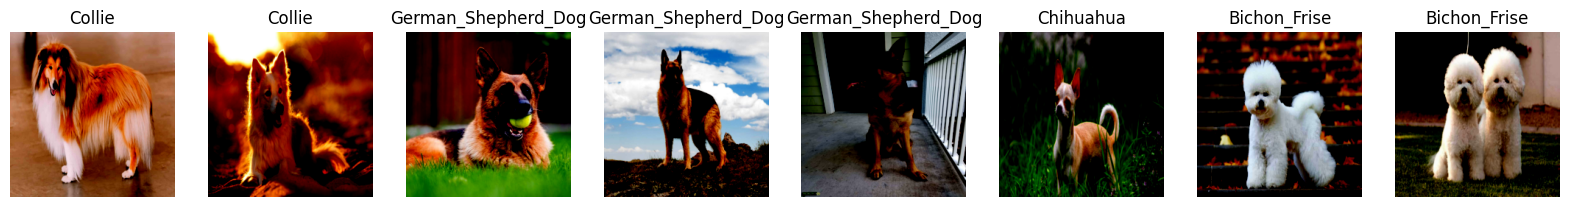

In [8]:
train_loader, val_loader, class_names = load_data(DATA_DIR, BATCH_SIZE)
visualize_data(train_loader, class_names)

# Training 

In [9]:
# === VISUALIZE SOME PREDICTIONS ===
def show_predictions(model, dataloader, title, class_names):
    """Visualize some predictions from the model."""
    model.eval()
    images, labels = next(iter(dataloader))
    images, labels = images.to(DEVICE), labels.to(DEVICE)
    with torch.no_grad():
        outputs = model(images)
        preds = outputs.argmax(dim=1)

    fig, axs = plt.subplots(2, 4, figsize=(12, 6))
    axs = axs.flatten()
    for i in range(8):
        img = images[i].permute(1, 2, 0).cpu().numpy()
        img = (img * 0.5) + 0.5  # unnormalize
        axs[i].imshow(img)
        axs[i].axis("off")
        axs[i].set_title(f"GT: {class_names[labels[i]]}\nPred: {class_names[preds[i]]}")
    plt.suptitle(title)
    plt.tight_layout()
    # plt.savefig(f"{title.replace(' ', '_')}.png")
    # print(f"Saved image predictions to: {title.replace(' ', '_')}.png")

In [10]:
# === MODEL SELECTOR ===
def get_model(name):
    if name == "efficientnet":
        model = efficientnet_b0(pretrained=True)
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, NUM_CLASSES)
    elif name == "vit":
        model = vit_b_16(pretrained=True)
        model.heads.head = nn.Linear(model.heads.head.in_features, NUM_CLASSES)
    else:
        raise ValueError("Unknown model")
    return model.to(DEVICE)

In [11]:
def get_model(name):
    if name == "efficientnet":
        weights = EfficientNet_B0_Weights.DEFAULT
        model = efficientnet_b0(weights=weights)
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, NUM_CLASSES)
    elif name == "vit":
        weights = ViT_B_16_Weights.DEFAULT
        model = vit_b_16(weights=weights)
        model.heads.head = nn.Linear(model.heads.head.in_features, NUM_CLASSES)
    else:
        raise ValueError("Unknown model")
    return model.to(DEVICE)

In [12]:
# === TRAIN FUNCTION ===
def train(model, model_name):
    writer = SummaryWriter(log_dir=os.path.join(RUNS_DIR, model_name))
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-4) 
    scheduler = StepLR(optimizer, step_size=3, gamma=0.5)

    # === LOAD DATA ===
    train_loader, val_loader, class_names = load_data(DATA_DIR, BATCH_SIZE)

    for epoch in range(EPOCHS):
        model.train()
        train_loss, train_correct = 0.0, 0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
            train_correct += (outputs.argmax(1) == labels).sum().item()
        train_acc = train_correct / len(train_loader.dataset)

        # === VALIDATION ===
        model.eval()
        val_loss, val_correct = 0.0, 0
        all_preds, all_labels = [], []
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
                outputs = model(inputs)
                val_loss += criterion(outputs, labels).item()
                preds = outputs.argmax(1)
                val_correct += (preds == labels).sum().item()
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
        val_acc = val_correct / len(val_loader.dataset)

        # === LOGGING ===
        writer.add_scalar("Loss/train", train_loss, epoch)
        writer.add_scalar("Loss/val", val_loss, epoch)
        writer.add_scalar("Accuracy/train", train_acc, epoch)
        writer.add_scalar("Accuracy/val", val_acc, epoch)

        print(f"[{epoch+1}/{EPOCHS}] Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

        scheduler.step()

    writer.close()

    # === CONFUSION MATRIX ===
    cm = confusion_matrix(all_labels, all_preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
    disp.plot(xticks_rotation=45)
    plt.title(f"{model_name} Confusion Matrix")
    plt.tight_layout()
    # plt.savefig(f"{model_name}_confusion_matrix.png")

    # === SHOW PREDICTIONS ===
    show_predictions(model, val_loader, f"{model_name} Sample Predictions", class_names)

    # === SAVE CHECKPOINT ===
    os.makedirs(CHECKPOINT_DIR, exist_ok=True)
    torch.save(model.state_dict(), os.path.join(CHECKPOINT_DIR, f"{model_name}_model.pt"))
    print(f"Model saved to {CHECKPOINT_DIR}/{model_name}_model.pt")

## EfficientNet

[1/10] Train Acc: 0.4213 | Val Acc: 0.8273
[2/10] Train Acc: 0.9222 | Val Acc: 0.9281
[3/10] Train Acc: 0.9602 | Val Acc: 0.9712
[4/10] Train Acc: 0.9910 | Val Acc: 0.9640
[5/10] Train Acc: 0.9855 | Val Acc: 0.9712
[6/10] Train Acc: 0.9855 | Val Acc: 0.9712
[7/10] Train Acc: 0.9964 | Val Acc: 0.9784
[8/10] Train Acc: 0.9928 | Val Acc: 0.9784
[9/10] Train Acc: 0.9946 | Val Acc: 0.9856
[10/10] Train Acc: 0.9946 | Val Acc: 0.9856
Model saved to checkpoints/efficientnet_model.pt


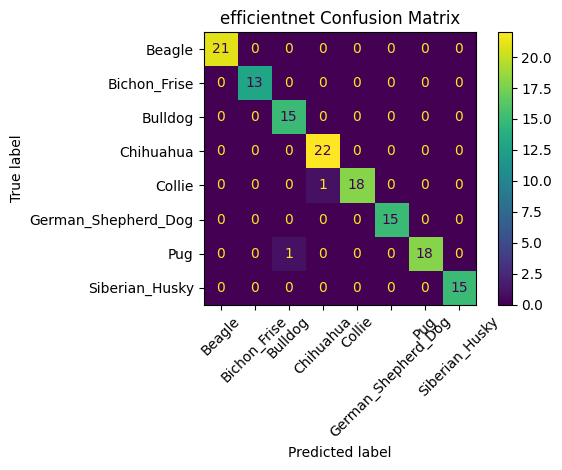

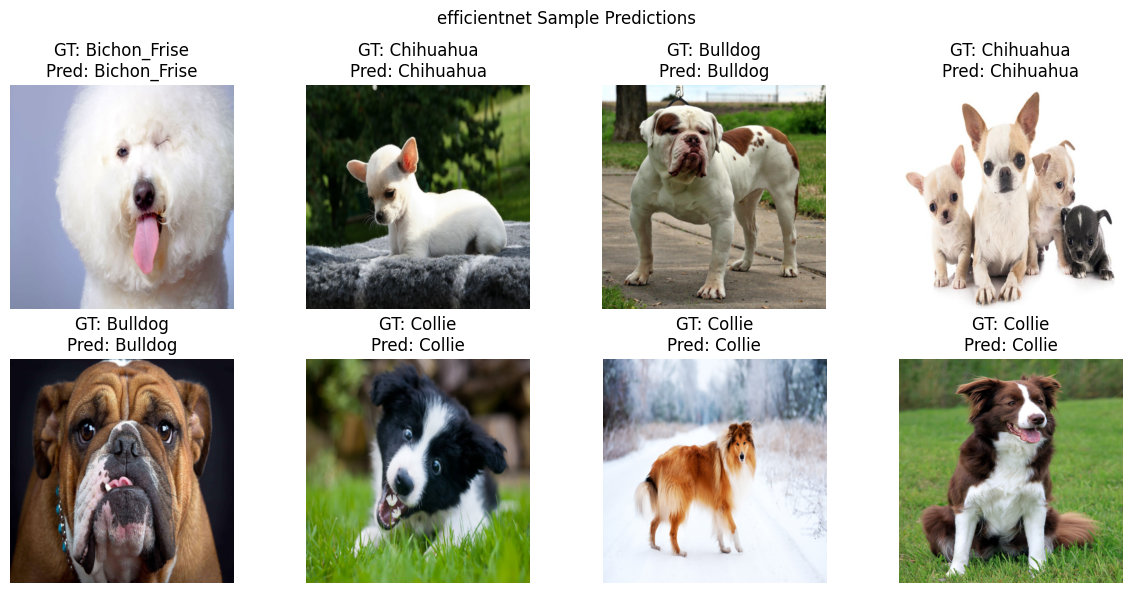

In [13]:
train(get_model("efficientnet"), "efficientnet")

## Vision Transformer

[1/10] Train Acc: 0.3924 | Val Acc: 0.7482
[2/10] Train Acc: 0.9168 | Val Acc: 0.9568
[3/10] Train Acc: 0.9693 | Val Acc: 0.9856
[4/10] Train Acc: 0.9837 | Val Acc: 0.9712
[5/10] Train Acc: 0.9928 | Val Acc: 0.9928
[6/10] Train Acc: 0.9964 | Val Acc: 0.9856
[7/10] Train Acc: 0.9928 | Val Acc: 0.9856
[8/10] Train Acc: 0.9892 | Val Acc: 1.0000
[9/10] Train Acc: 1.0000 | Val Acc: 0.9928
[10/10] Train Acc: 0.9982 | Val Acc: 0.9856
Model saved to checkpoints/efficientnet_model.pt


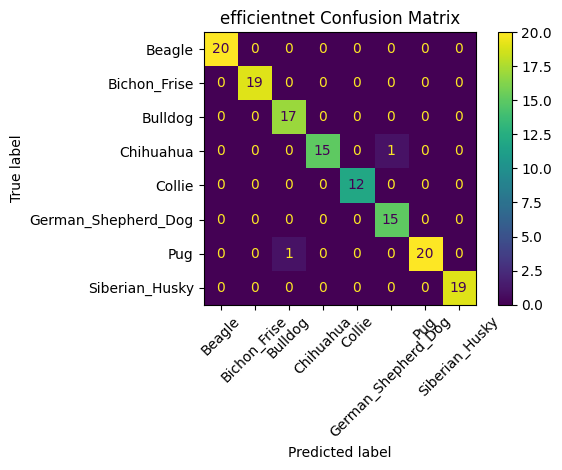

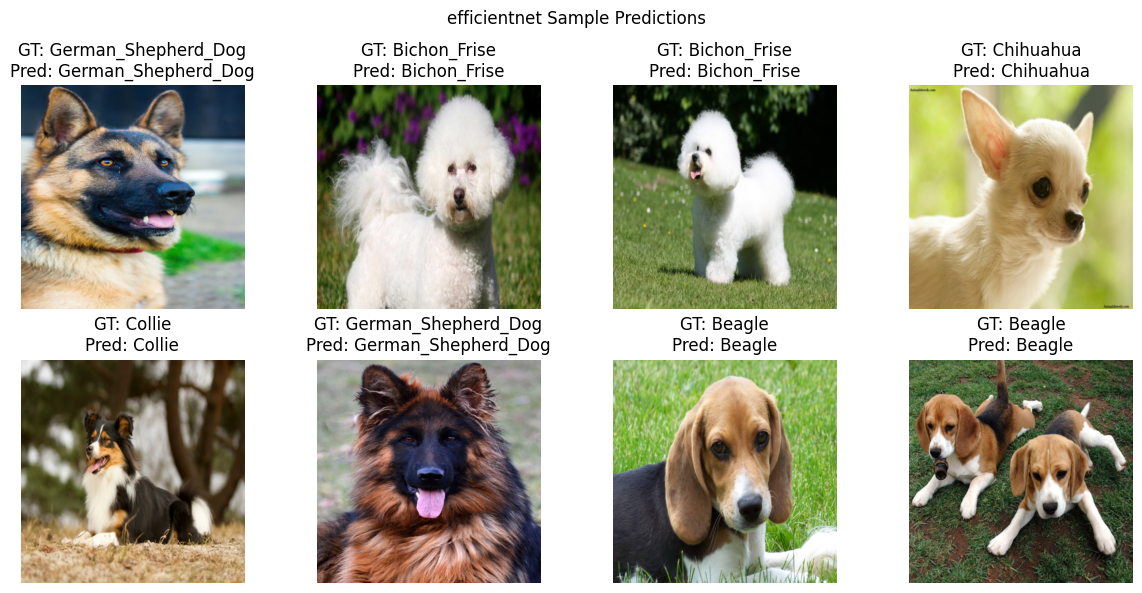

In [14]:
train(get_model("efficientnet"), "efficientnet")

## TensorBoard

In [15]:
import subprocess
import time
import webbrowser

In [16]:
def start_tensorboard(logdir="runs", port=6006):
    """
    Starts TensorBoard as a background process and opens it in your default browser.
    Returns the process handle so you can terminate it later.
    """
    tb_cmd = [
        "tensorboard",
        f"--logdir={logdir}",
        f"--port={port}",
        "--host=localhost"
    ]
    
    # Start the process
    print(f"Starting TensorBoard on port {port}...")
    process = subprocess.Popen(tb_cmd)
    
    # Give it a second to get going
    time.sleep(2)
    
    # Open in browser automatically
    url = f"http://localhost:{port}"
    print(f"Opening {url} in your default browser...")
    webbrowser.open(url)
    
    return process


def stop_tensorboard(process):
    """
    Stops the TensorBoard process started by `start_tensorboard()`.
    """
    print("Stopping TensorBoard...")
    process.terminate()  # or process.kill()


In [17]:
process = start_tensorboard(logdir="runs", port=6008)

Starting TensorBoard on port 6008...


TensorFlow installation not found - running with reduced feature set.

NOTE: Using experimental fast data loading logic. To disable, pass
    "--load_fast=false" and report issues on GitHub. More details:
    https://github.com/tensorflow/tensorboard/issues/4784

E0421 16:30:58.241353 127317006960448 program.py:300] TensorBoard could not bind to port 6008, it was already in use
ERROR: TensorBoard could not bind to port 6008, it was already in use


Opening http://localhost:6008 in your default browser...


In [18]:
# stop_tensorboard(process)